In [11]:
from typing import Callable
from itertools import tee
from functools import partial
from time import perf_counter

import numpy as np

import jax

from jax import numpy as jnp
from jax import Array

import equinox as eqx

from atr.states import TransverseFieldSpectrum, IsingSpectrum
from atr.operator import operator_expect_and_variance, operator_expect, Z, ZZ, X, XX
from atr.operator.spin import to_dense
from atr.transport import inverse_power_update
from atr.graph import Cube
from atr.models import ResidualRBM
from atr.sampler import SpinSampler
from atr.models import model_params, param_count
from atr.utils import default_complex_dtype, vmap, Trajectory
from atr.linalg import SoftSpectralSolver

import matplotlib.pyplot as plt

In [12]:
class InitialCondition(eqx.Module):

    init_cond: Callable
    model: eqx.Module
    coeffs: Array

    def __init__(self, init_cond, model):
        self.init_cond = init_cond
        self.model = model
        self.coeffs = jnp.array([1.0, 1.0])

    def __call__(self, x: Array) -> Array:
        a, b = self.coeffs
        return a * self.init_cond(x) + b * self.model(x)

In [13]:
def cosine_schedule(max_val, min_val, n_steps, start=0.0, end=1.0):

    assert 0.0 <= start < end <= 1.0, "Start and end must be in the range [0, 1] and start < end."
    start_step, end_step = int(start * n_steps), int(end * n_steps)

    def schedule(step):
        scaled_step = (step - start_step) / (end_step - start_step)
        scaled_step = jnp.clip(scaled_step, 0.0, 1.0)
        return min_val + (max_val - min_val) * jnp.cos(jnp.pi * scaled_step / 2) ** 2

    return schedule

In [14]:
key = jax.random.PRNGKey(42)

In [15]:
graph = Cube((10,), pbc=True)

In [16]:
sampler = SpinSampler(graph.shape, n_samples=64, n_chains=4)

In [17]:
spectrum = TransverseFieldSpectrum(graph, corrected=True)
ctype = default_complex_dtype()

def init_logpsi(x):
    psi = spectrum.excited_state(x)[0]
    return jnp.log(psi.astype(ctype) + 1e-4)

key, init_key = jax.random.split(key, 2)
nqs = ResidualRBM(graph.shape, n_channels=4, n_blocks=2, kernel_size=5, key=init_key)

logpsi = InitialCondition(init_logpsi, nqs)

In [18]:
li, lf = 0.0, 1.0
npts = 20
alpha = 3.0

idx = jnp.linspace(0, 1, npts)
lambda_grid = lf * (1 - jnp.exp(-alpha * idx)) / (1 - jnp.exp(-alpha))

print(lambda_grid)

lambda_grid = lambda_grid.tolist()

[0.         0.15371327 0.28497508 0.39706483 0.49278268 0.57452
 0.64431864 0.7039225  0.75482064 0.7982845  0.8354001  0.8670945
 0.8941597  0.9172717  0.9370079  0.9538615  0.9682534  0.98054326
 0.9910381  1.        ]


In [19]:
H0, V = -X(graph), -ZZ(graph)

## ED reference data

In [24]:
# @eqx.filter_jit
@partial(vmap, chunk_size=20)
def ed_energies(l):
    Hmat = to_dense(H0 + l * V)
    energies = jnp.linalg.eigvalsh(Hmat)
    return energies[:2]

In [25]:
ed_grid = jnp.linspace(li, lf, 50)
ed_energies = ed_energies(ed_grid)

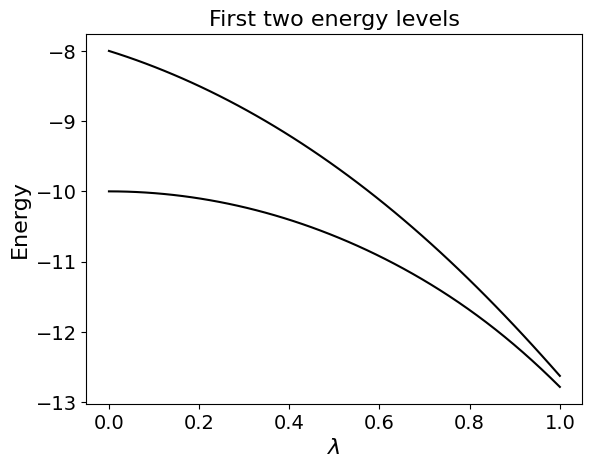

In [33]:
plt.plot(ed_grid, ed_energies, label="ED", color="black")
plt.xlabel(r"$\lambda$", fontsize=16)
plt.ylabel("Energy", fontsize=16)
plt.title("First two energy levels", fontsize=16)
plt.xticks(fontsize=14)
_ = plt.yticks(fontsize=14)

In [ ]:
@eqx.filter_jit
def estimate_energy(logpsi, H, key):
    samples = sampler(logpsi, key).reshape(-1, *graph.shape)
    return operator_expect_and_variance(H, logpsi, samples) # chunk_size=config.chunk_size)

In [ ]:
@eqx.filter_jit
def update_energy(logpsi, energy, potential, step_size, key):
    samples = sampler(logpsi, key).reshape(-1, *graph.shape)
    V_exp = operator_expect(potential, logpsi, samples) #, chunk_size=config.chunk_size)
    return energy + step_size * V_exp

In [ ]:
linear_solver = SoftSpectralSolver(rcond=1e-5, acond=1e-7)
dampening_schedule = cosine_schedule(0.2, 1e-3, 100, start=0.0, end=0.9)

@eqx.filter_jit
def inverse_power_iter(logpsi, hamiltonian, target_energy, i, key):

    samples = sampler(logpsi, key).reshape(-1, *graph.shape)

    E, E_var = operator_expect_and_variance(
        hamiltonian, logpsi, samples, # chunk_size=config.chunk_size
    )

    d_logpsi = inverse_power_update(
        logpsi,
        samples,
        hamiltonian,
        target_energy,
        solver=linear_solver,
        # diag_shift=config.diag_shift,
        # chunk_size=config.chunk_size,
    )

    d_logpsi = jax.tree.map(lambda x: dampening_schedule(i) * x, d_logpsi)
    logpsi_ = eqx.apply_updates(logpsi, d_logpsi)

    return logpsi_, (E, E_var)

In [ ]:
max_ipi = 100
var_cutoff = 1e-4
var_lookback = 10

def optimize_state(logpsi, hamiltonian, target_energy, key):

    print(f"\n###### Inverse power iteration: E_ref = {target_energy:.4e} ######\n")

    energies, variances = [], []
    n_spins = graph.num_nodes

    i = 0
    control = 1000.0

    clock = perf_counter()
    global_clock = perf_counter()

    while (control > var_cutoff and i < max_ipi) or i < var_lookback:

        i += 1

        key = jax.random.fold_in(key, i)
        logpsi, (energy, var) = inverse_power_iter(logpsi, hamiltonian, target_energy, i, key)

        energies.append(energy.item())
        variances.append(var.item())
        control = np.std(variances[-var_lookback :]) / n_spins

        if perf_counter() - clock > 10:

            time_per_step = (perf_counter() - global_clock) / i
            dampening = dampening_schedule(i)
            vps = var / n_spins

            print(
                f"Step {i:3} | Energy: {energy:.4e} | VPS: {vps:.4e} | Control: {control:.2e} | Dampening: {dampening:.2e} | Time per step: {time_per_step:.2f} s"
            )
            clock = perf_counter()

    print(f"\n##### Final energy: {energy:.4e} | Final variance: {var:.4e} #####\n")

    return logpsi

In [ ]:
key, key1, key2 = jax.random.split(key, 3)

In [ ]:
step_size = lambda_grid[1] - lambda_grid[0]

samples = sampler(logpsi.init_cond, key).reshape(-1, *graph.shape)
E0 = operator_expect(H0, logpsi.init_cond, samples) #, chunk_size=config.chunk_size)
target_energy = update_energy(logpsi.init_cond, E0, V, step_size, key1)

print(f"Initial energy: {E0:.10e}")
print(f" Target energy: {target_energy:.10e}")

H = H0 + step_size * V
logpsi = optimize_state(logpsi, H, target_energy, key2)
lambda_grid.pop(0)

In [ ]:
E, E_var = estimate_energy(logpsi, H, key2)

In [ ]:
print(f"Lambda value: {lambda_grid[0]:.4f}")
print(f"Eigenstate energy: {E:.10e}")
print(f"Energy variance  : {E_var:.10e}")

In [ ]:
def pairs(iterable):
    a, b = tee(iterable)
    next(b, None)
    return zip(a, b)

In [ ]:
y = [model_params(logpsi)]
energies = [E.item()]
energy_vars = [E_var.item()]

clock = perf_counter()

for i, (li, lf) in enumerate(pairs(lambda_grid)):

    key_ = jax.random.fold_in(key, i)
    key1, key2, key3 = jax.random.split(key_, 3)

    step_size = lf - li
    H = H0 + lf * V

    target_energy = update_energy(logpsi, E, V, step_size, key1)
    logpsi = optimize_state(logpsi, H, target_energy, key2)
    E, E_var = estimate_energy(logpsi, H, key3)

    y.append(model_params(logpsi))
    E, E_var = E.item(), E_var.item()
    energies.append(E)
    energy_vars.append(E_var)

    time_per_step = (perf_counter() - clock) / (i + 1)

    print(
        f"Iteration {i+1:4} | Lambda: {lf:.4e} | Step size {step_size:.4e} | Energy {E:.4e} | Energy var. {E_var:.4e} | Time per step: {time_per_step:.4e}"
    )

In [ ]:
t = jnp.array(lambda_grid)
y = jax.tree.map(lambda *l: jnp.stack(l), *y)

energy_data = jnp.stack([jnp.stack(energies), jnp.stack(energy_vars)], axis=1)
data = {"energies": energy_data}

trajectory = Trajectory(t, y, data)